# Importing Required Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')

# Loading Dataset

In [2]:
train = pd.read_csv('train.csv', parse_dates=['Date'], low_memory=False)
store = pd.read_csv('store.csv')

# Merge Store Info into Training Data

In [3]:
df = train.merge(store, on='Store', how='left')

# Filter: Only "Open" stores with "sales > 0"

In [4]:
df = df[(df['Open']==1) & (df['Sales']>0)]

df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


# Exploratory Data Analysis (EDA)

Basic stats

In [5]:
print('Dataset Shape:',df.shape)
print('\nMissing Values:\n', df.isnull().sum())
print('\nSales Summary:\n', df['Sales'].describe())

Dataset Shape: (844338, 18)

Missing Values:
 Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2186
CompetitionOpenSinceMonth    268600
CompetitionOpenSinceYear     268600
Promo2                            0
Promo2SinceWeek              423292
Promo2SinceYear              423292
PromoInterval                423292
dtype: int64

Sales Summary:
 count    844338.000000
mean       6955.959134
std        3103.815515
min          46.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64


# --- Plot 1: Sales Distribution ---

Text(0.5, 0, 'Sales')

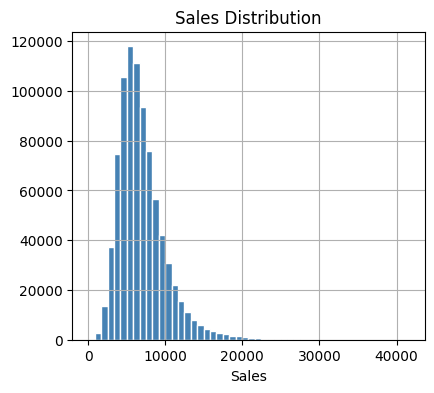

In [6]:

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['Sales'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Sales Distribution')
plt.xlabel('Sales')

# --- Plot 2: Average sales by day of week ---

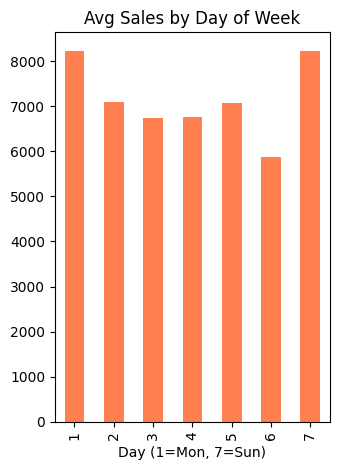

In [7]:

plt.subplot(1, 2, 2)
df.groupby('DayOfWeek')['Sales'].mean().plot(kind='bar', color='coral')
plt.title('Avg Sales by Day of Week')
plt.xlabel('Day (1=Mon, 7=Sun)')
plt.tight_layout()
plt.show()


# --- Plot 3: Sales over time (sample store) ---

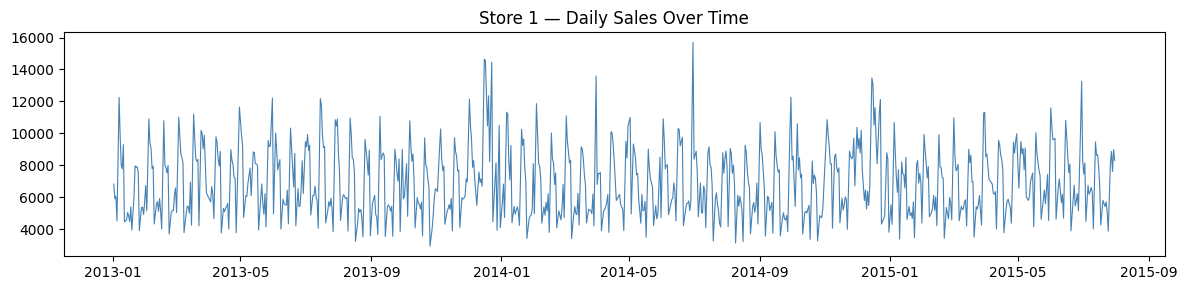

In [8]:
sample = df[df['Store'] == 3].sort_values('Date')
plt.figure(figsize=(12, 3))
plt.plot(sample['Date'], sample['Sales'], linewidth=0.8, color='steelblue')
plt.title('Store 1 — Daily Sales Over Time')
plt.tight_layout()
plt.show()

# Feature Engineering: 

# 1. Extract date features

In [9]:

df['Year']         = df['Date'].dt.year
df['Month']        = df['Date'].dt.month
df['Day']          = df['Date'].dt.day
df['WeekOfYear']   = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend']    = (df['DayOfWeek'] >= 6).astype(int)
df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
df['IsMonthEnd']   = df['Date'].dt.is_month_end.astype(int)
df['Quarter']      = df['Date'].dt.quarter  

# 2. Interaction features (combinations that boost accuracy)

In [10]:
df['Promo_Weekend']    = df['Promo'] * df['IsWeekend']       # promo on weekend?
df['Promo_Month']      = df['Promo'] * df['Month']           # which month has promo?
df['Store_DayOfWeek']  = df['Store'] * df['DayOfWeek']       # store+day combo

# 3. Competition feature (closer = more competition pressure)

In [11]:
df['CompetitionDistance'].fillna(df['CompetitionDistance'].median(), inplace=True)
df['NearCompetitor'] = (df['CompetitionDistance'] < 1000).astype(int)  # within 1km

# 4. Encode categoricals

In [12]:
df['StoreType']    = df['StoreType'].astype('category').cat.codes
df['Assortment']   = df['Assortment'].astype('category').cat.codes
df['StateHoliday'] = df['StateHoliday'].astype('category').cat.codes

# 5. Filling remaining missing values

In [13]:
df['Promo2'].fillna(0, inplace=True)

In [14]:
# 6. Updated feature list (added new features)

In [15]:
FEATURES = [
    'Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday',
    'StoreType', 'Assortment', 'CompetitionDistance', 'Promo2',
    'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend',
    'IsMonthStart', 'IsMonthEnd','Quarter',                                    
    'Promo_Weekend', 'Promo_Month',               
    'Store_DayOfWeek', 'NearCompetitor'           
]

TARGET = 'Sales'
X = df[FEATURES]
y = df[TARGET]

print("Total features:", len(FEATURES))
print("Features:", FEATURES)
print("X shape:", X.shape)

Total features: 21
Features: ['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'Promo2', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'Quarter', 'Promo_Weekend', 'Promo_Month', 'Store_DayOfWeek', 'NearCompetitor']
X shape: (844338, 21)


# Training / Evaluateing Model

# 1. Train-Test Split (80/20)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 2. Training XGBoost Model

In [17]:

model = XGBRegressor(
    n_estimators=1000,          # more trees = better learning
    learning_rate=0.03,         # slower, more careful
    max_depth=8,                # deeper trees catch more patterns
    subsample=0.85,             
    colsample_bytree=0.75,      
    min_child_weight=5,         # prevents overfitting on rare cases
    gamma=0.1,                  # adds regularisation
    reg_alpha=0.1,              # L1 regularisation
    reg_lambda=1.0,             # L2 regularisation
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=200                 # prints progress every 200 trees
)

[0]	validation_0-rmse:3081.13927
[200]	validation_0-rmse:1783.44956
[400]	validation_0-rmse:1344.39630
[600]	validation_0-rmse:1118.58808
[800]	validation_0-rmse:1001.34832
[999]	validation_0-rmse:921.96352


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.75
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# KPI Evaluation

In [18]:
y_pred = model.predict(X_test)

# Core regression KPIs

In [19]:
rmse         = np.sqrt(mean_squared_error(y_test, y_pred))
mae          = mean_absolute_error(y_test, y_pred)
r2           = r2_score(y_test, y_pred)
mape         = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
within_10pct = np.mean(np.abs((y_test - y_pred) / y_test) < 0.10) * 100
within_20pct = np.mean(np.abs((y_test - y_pred) / y_test) < 0.20) * 100 

avg_sales    = y_test.mean()
mae_pct      = (mae / avg_sales) * 100   

# Prediction

In [20]:
print("=" * 45)
print("         MODEL ACCURACY REPORT")
print("=" * 45)
print(f"  R² Score             : {r2:.4f}  ({r2*100:.1f}%)")
print(f"  RMSE                 : €{rmse:,.2f}")
print(f"  MAE                  : €{mae:,.2f}  ({mae_pct:.1f}% of avg sales)")
print(f"  MAPE                 : {mape:.2f}%")
print(f"  Within 10% accuracy  : {within_10pct:.1f}%")
print(f"  Within 20% accuracy  : {within_20pct:.1f}%")          # NEW
print("=" * 45)
print(f"\n  Average actual sales : €{avg_sales:,.0f}")
print(f"  Typical daily error  : €{mae:,.0f}")

         MODEL ACCURACY REPORT
  R² Score             : 0.9119  (91.2%)
  RMSE                 : €921.96
  MAE                  : €644.80  (9.3% of avg sales)
  MAPE                 : 10.23%
  Within 10% accuracy  : 62.5%
  Within 20% accuracy  : 88.8%

  Average actual sales : €6,959
  Typical daily error  : €645


# 4. Plot: Actual vs Predicted

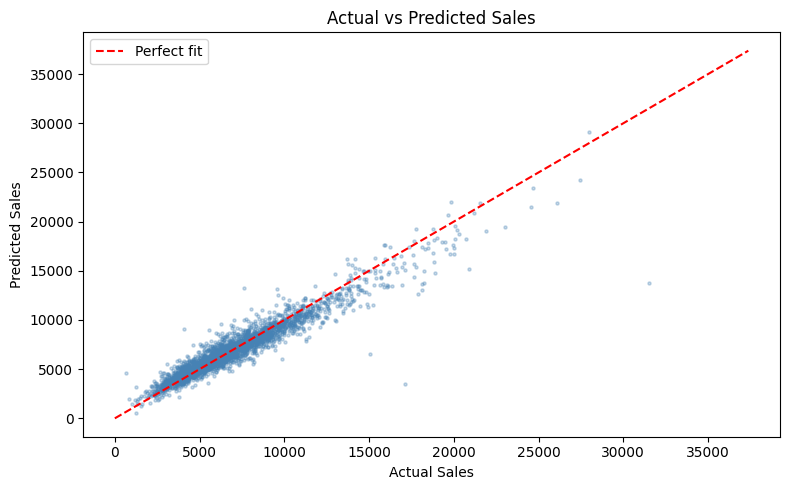

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test[:3000], y_pred[:3000], alpha=0.3, s=5, color='steelblue')
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--', linewidth=1.5, label='Perfect fit')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.tight_layout()
plt.show()

# 5. Feature Importance

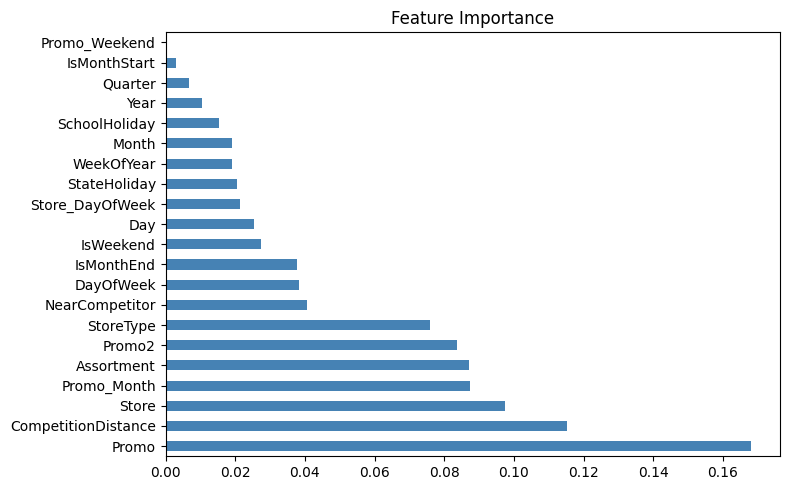

In [22]:
feat_imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
feat_imp.plot(kind='barh', figsize=(8, 5), color='steelblue', title='Feature Importance')
plt.tight_layout()
plt.show()

# Saving the Model

In [23]:
joblib.dump(model, 'sales_model.pkl')
print("Model saved as sales_model.pkl")

Model saved as sales_model.pkl
